# Modele: Classification du facteur de Risque des Seismes

Ce notebook compare 3 modèles de Machine Learning et enregistre les paramètres,
 métriques et datasets sur le serveur MLflow cible (`http://194.238.26.226:5000`).

**Algorithmes evalues :**
1. LightGBM
2. XGBoost
3. Random Forest


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import shap

# --- Intégration MLflow ---
import mlflow
import mlflow.sklearn
from mlflow.data.pandas_dataset import PandasDataset

In [2]:
# Configuration du serveur de suivi MLflow
MLFLOW_TRACKING_URI = "http://194.238.26.226:5000"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("Risk_Factors_Model_4")

trusted_types = [
    "sklearn.metrics._dist_metrics.EuclideanDistance64",
    "sklearn.neighbors._kd_tree.KDTree",
    "sklearn.tree._tree.Tree"
    "collections.OrderedDict", 
    "lightgbm.basic.Booster", 
    "lightgbm.sklearn.LGBMClassifier",
    "collections.OrderedDict",
    "xgboost.core.Booster", 
    "xgboost.sklearn.XGBClassifier"
]

In [3]:
# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


## 1. Chargement des données

In [4]:
file_path = os.path.join("data", "usgs_earthquakes_2025.csv")
df = pd.read_csv(file_path)

print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])
df.head()

Nombre de lignes : 29062
Nombre de colonnes : 35


,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,alert,status,tsunami,sig,net,code,ids,sources,types,nst,dmin,rms,gap,magType,type,title,longitude,latitude,depth,event_id,date_time,year,month,day,hour
0,4.2,"70 km W of Abra Pampa, Argentina",1751241591065,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,271,us,7000q9mu,",us7000q9mu,",",us,",",origin,phase-data,",19.0,1.696,0.70,89.0,mb,earthquake,"M 4.2 - 70 km W of Abra Pampa, Argentina",-66.3753,-22.6251,247.528,us7000q9mu,2025-06-29 23:59:51.065000+00:00,2025,6,29,23
1,2.5,"1 km E of Nikolski, Alaska",1751241495097,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,96,us,7000qb5r,",ak0258a2rwky,us7000qb5r,",",ak,us,",",origin,phase-data,",17.0,0.035,0.42,198.0,ml,earthquake,"M 2.5 - 1 km E of Nikolski, Alaska",-168.8412,52.9376,61.149,us7000qb5r,2025-06-29 23:58:15.097000+00:00,2025,6,29,23
2,2.8,"31 km SSE of Nikolski, Alaska",1751241219318,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,121,us,7000qb5v,",ak0258a2qvpj,us7000qb5v,",",ak,us,",",origin,phase-data,",10.0,0.316,0.51,231.0,ml,earthquake,"M 2.8 - 31 km SSE of Nikolski, Alaska",-168.6544,52.6804,35.000,us7000qb5v,2025-06-29 23:53:39.318000+00:00,2025,6,29,23
3,3.8,"153 km S of Nikolski, Alaska",1751241150341,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,222,us,7000q9mt,",ak0258a2qnbw,us7000q9mt,",",ak,us,",",origin,phase-data,",55.0,1.411,0.42,185.0,mb,earthquake,"M 3.8 - 153 km S of Nikolski, Alaska",-168.5438,51.5761,10.000,us7000q9mt,2025-06-29 23:52:30.341000+00:00,2025,6,29,23
4,4.5,"185 km WSW of Tual, Indonesia",1751240317514,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,312,us,7000q9mq,",us7000q9mq,",",us,",",origin,phase-data,",31.0,3.637,0.48,93.0,mb,earthquake,"M 4.5 - 185 km WSW of Tual, Indonesia",131.2977,-6.4544,35.000,us7000q9mq,2025-06-29 23:38:37.514000+00:00,2025,6,29,23


## 2. Construction de la variable cible ($y$) : `target_risk_category`

La variable cible $y$ est générée à l'aide d'une fonction de règle métier séquentielle (`define_risk_category`) appliquée ligne par ligne sur le dataset des séismes (`df.apply(..., axis=1)`). Elle segmente les séismes en 5 catégories hiérarchisées selon un ordre de priorité décroissant :

1. **Risque Tsunami** (`'Risque Tsunami'`)
   * **Condition :** Attribué en priorité absolue si le paramètre `tsunami` est égal à $1$.

2. **Forte Secousse** (`'Forte Secousse'`)
   * **Condition :** Si le séisme n'a pas déclenché d'alerte tsunami, il est classé ici dès que la magnitude (`mag`) est supérieure ou égale à $6.5$ **ou** que l'intensité maximale ressentie (`mmi`) est supérieure ou égale à $7.0$ (en s'assurant que les valeurs ne sont pas nulles via `pd.notna`).

3. **Forte Exposition** (`'Forte Exposition'`)
   * **Condition :** Cette catégorie s'applique si le niveau d'alerte (`alert`) est `'orange'` ou `'red'`, **ou** si le nombre de rapports de ressenti (`felt`) dépasse $1,000$ personnes, **ou** si l'indicateur d'importance/signifiance (`sig`) dépasse $600$.

4. **Faible Profondeur** (`'Faible Profondeur'`)
   * **Condition :** Cible les séismes superficiels mais potentiellement destructeurs lorsque la profondeur (`depth`) est inférieure ou égale à $15\text{ km}$ **et** que la magnitude (`mag`) atteint au moins $4.0$.

5. **Risque Modéré ou Faible** (`'Risque Modéré ou Faible'`)
   * **Condition :** C'est la catégorie par défaut (Fallback / Priorité 5) attribuée à tous les séismes ne remplissant aucun des critères critiques ci-dessus.

In [5]:
def define_risk_category(row):
    # Priority 1: Risque Tsunami
    if row.get('tsunami') == 1:
        return 'Risque Tsunami'
    
    # Priority 2: Forte Secousse
    mag = row.get('mag', 0)
    mmi = row.get('mmi', 0)
    if (pd.notna(mag) and mag >= 6.5) or (pd.notna(mmi) and mmi >= 7.0):
        return 'Forte Secousse'
    
    # Priority 3: Forte Exposition
    alert = row.get('alert')
    felt = row.get('felt', 0)
    sig = row.get('sig', 0)
    if (alert in ['orange', 'red']) or (pd.notna(felt) and felt > 1000) or (pd.notna(sig) and sig > 600):
        return 'Forte Exposition'
    
    # Priority 4: Faible Profondeur
    depth = row.get('depth')
    if pd.notna(depth) and pd.notna(mag) and (depth <= 15) and (mag >= 4.0):
        return 'Faible Profondeur'
    
    # Priority 5: Défaut
    return 'Risque Modéré ou Faible'

# Application de la règle métier
df['target_risk_category'] = df.apply(define_risk_category, axis=1)


## 3. Préparation des données & Normalisation

### 1. Sélection des caractéristiques (*Features*) et de la cible (*Target*)

* **Variables conservées dans $X$** :
  * **Numériques (`feature_cols_num`)** : `mag`, `depth`, `nst`, `dmin`, `rms`, `gap`, `latitude`, `longitude`.
  * **Catégoriques (`feature_cols_cat`)** : `magType`.
* **Variable cible (`y`)** : `target_risk_category` (encodée ensuite sous forme numérique via `LabelEncoder`).

> **Remarque importante concernant la matrice $X$ (Features) :**  
> Les variables ayant servi directement à la définition de la variable cible `target_risk_category` (notamment `tsunami`, `mmi`, `alert`, `felt`, `sig`, ainsi que certaines conditions combinées sur `mag` et `depth`) **ne sont pas incluses** dans la matrice de caractéristiques $X$ afin d'éviter tout risque de fuite de données (*data leakage*).

---

### 2. Gestion des valeurs manquantes (*Imputation*)

* **Imputation par la médiane (`nst`, `dmin`, `gap`)** : Remplacement des valeurs manquantes par la valeur médiane de chaque colonne afin de limiter l'impact des valeurs extrêmes (*outliers*).
* **Imputation catégorique (`magType`)** : Attribution de la valeur par défaut `'unknown'` aux valeurs manquantes pour éviter de supprimer des observations.

---

### 3. Encodage des variables catégoriques

* **`pd.get_dummies(...)`** : Transformation de la variable `magType` en variables binaires (*One-Hot Encoding*). Chaque type de magnitude devient une colonne distincte contenant des `0` ou des `1`.

---

### 4. Harmonisation des types de données

* **`X = X.astype(float)`** : Conversion de l'ensemble de la matrice $X$ en type `float64`. Cela garantit un format uniforme et élimine les avertissements de compatibilité lors du suivi des métriques et artefacts avec MLflow.

---

### 5. Division des données (*Train / Test Split*)

* **`train_test_split(...)`** : Séparation du jeu de données en deux ensembles (80 % pour l'entraînement et 20 % pour le test).
* **`stratify=y_encoded`** : Maintien des proportions de chaque catégorie de risque dans les deux sous-ensembles, évitant ainsi tout biais d'échantillonnage.
* **`random_state=42`** : Garantie de la reproductibilité exacte de la séparation.

---

### 6. Normalisation des variables numériques

* **`StandardScaler()`** : Centrage-réduction des caractéristiques numériques (`feature_cols_num`) pour obtenir une moyenne de 0 et un écart-type de 1.
* **`fit_transform` sur `X_train`** : Calcul des paramètres (moyenne et écart-type) uniquement sur l'ensemble d'entraînement, puis application de la transformation.
* **`transform` sur `X_test`** : Application des mêmes paramètres calculés sur le jeu d'entraînement à l'ensemble de test afin de prévenir toute fuite d'information (*data leakage*).

In [6]:
feature_cols_num = ['mag', 'depth', 'nst', 'dmin', 'rms', 'gap', 'latitude', 'longitude']
feature_cols_cat = ['magType']

X = df[feature_cols_num + feature_cols_cat].copy()
y = df['target_risk_category']

for col in ['nst', 'dmin', 'gap']:
    X[col] = X[col].fillna(X[col].median())

X['magType'] = X['magType'].fillna('unknown')

# Encodage catégorique
X = pd.get_dummies(X, columns=feature_cols_cat, drop_first=False)

# Conversion propre de TOUTES les colonnes en float64 (résout l'avertissement MLflow)
X = X.astype(float)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split Stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Normalisation des variables numériques
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[feature_cols_num] = scaler.fit_transform(X_train[feature_cols_num])
X_test_scaled[feature_cols_num] = scaler.transform(X_test[feature_cols_num])


## 4. Entraînement des modèles & Logging MLflow

In [7]:
# Conversion de y_train en Série Pandas avec son index et nom de colonne
y_train_series = pd.Series(
    y_train, index=X_train.index, name="target_risk_category"
)

X_train_raw_df = X_train.copy().astype(float)
# Création des objets Dataset pour MLflow
dataset_train_raw = mlflow.data.from_pandas(
    pd.concat([X_train_raw_df, y_train_series], axis=1), 
    targets='target_risk_category', 
    name="USGS_Train_Raw"
)

X_train_scaled_df = X_train_scaled.copy().astype(float)
dataset_train_scaled = mlflow.data.from_pandas(
    pd.concat([X_train_scaled_df, pd.Series(y_train, index=X_train_scaled.index, name='target_risk_category')], axis=1), 
    targets='target_risk_category', 
    name="USGS_Train_Scaled"
)

models = {
    "LightGBM": {
    "model": LGBMClassifier(
        n_estimators=100, 
        max_depth=10, 
        class_weight='balanced', 
        random_state=42, 
        n_jobs=-1,
        verbose=-1
    ),
    "scaled": False,
    "dataset": dataset_train_raw,
    "params": {"n_estimators": 100, "max_depth": 10, "class_weight": "balanced"}
    },
    "XGBoost": {
    "model": XGBClassifier(
        n_estimators=100, 
        max_depth=6, 
        random_state=42, 
        n_jobs=-1
    ),
    "scaled": False,
    "dataset": dataset_train_raw,
    "params": {"n_estimators": 100, "max_depth": 6}
    },
        "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, max_depth=18, class_weight='balanced', random_state=42, n_jobs=-1),
        "scaled": False,
        "dataset": dataset_train_raw,
        "params": {"n_estimators": 100, "max_depth": 18, "class_weight": "balanced"}
    }

}

predictions = {}

for name, config in models.items():
    print(f"\n--- Entraînement et enregistrement MLflow : {name} ---")
    
    model = config["model"]
    is_scaled = config["scaled"]
    mlflow_dataset = config["dataset"]
    
    # Sélection des données appropriées
    X_tr = X_train_scaled if is_scaled else X_train
    X_te = X_test_scaled if is_scaled else X_test
    
    with mlflow.start_run(run_name=name):
        # 1. Log du Dataset
        mlflow.log_input(mlflow_dataset, context="training")
        
        # 2. Entraînement
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        predictions[name] = y_pred
        
        # 3. Calcul des Métriques
        acc = accuracy_score(y_test, y_pred)
        prec_w = precision_score(y_test, y_pred, average='weighted')
        rec_w = recall_score(y_test, y_pred, average='weighted')
        f1_w = f1_score(y_test, y_pred, average='weighted')
        f1_m = f1_score(y_test, y_pred, average='macro')
        
        # 4. Log des Paramètres
        mlflow.log_params(config["params"])
        mlflow.log_param("scaled_features", is_scaled)
        mlflow.log_param("num_features", X_tr.shape[1])
        mlflow.log_param("random_state", 42)
        
        # 5. Log des Métriques
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision_weighted", prec_w)
        mlflow.log_metric("recall_weighted", rec_w)
        mlflow.log_metric("f1_score_weighted", f1_w)
        mlflow.log_metric("f1_score_macro", f1_m)
        
        # 6. Log du Modèle dans l'artefact storage de MLflow
        mlflow.sklearn.log_model(model, name=name + "_model", skops_trusted_types=trusted_types)
        
        print(f"[{name}] Logged successfully to MLflow (F1-Macro: {f1_m:.4f})")


--- Entraînement et enregistrement MLflow : LightGBM ---


C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


[LightGBM] Logged successfully to MLflow (F1-Macro: 0.6949)
🏃 View run LightGBM at: http://194.238.26.226:5000/#/experiments/169/runs/be1fce4e82a64774b235671c0cffb9a3
🧪 View experiment at: http://194.238.26.226:5000/#/experiments/169

--- Entraînement et enregistrement MLflow : XGBoost ---
[XGBoost] Logged successfully to MLflow (F1-Macro: 0.6564)
🏃 View run XGBoost at: http://194.238.26.226:5000/#/experiments/169/runs/aba0f43eaedf4f21809337124ba2020a
🧪 View experiment at: http://194.238.26.226:5000/#/experiments/169

--- Entraînement et enregistrement MLflow : Random Forest ---
[Random Forest] Logged successfully to MLflow (F1-Macro: 0.6671)
🏃 View run Random Forest at: http://194.238.26.226:5000/#/experiments/169/runs/245453d768d448b9a1d2fc9229537538
🧪 View experiment at: http://194.238.26.226:5000/#/experiments/169


## 5. Comparaison des performances & Métriques

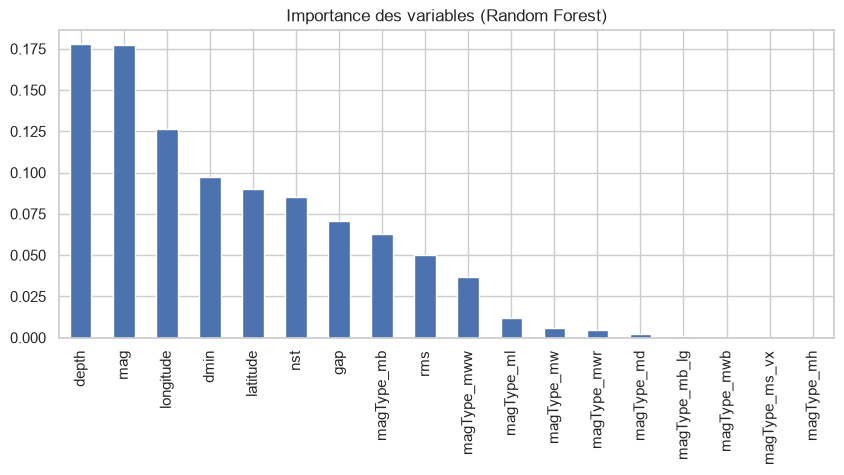

In [8]:
rf = models["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 4))
plt.title("Importance des variables (Random Forest)")
plt.show()


=== TABLEAU COMPARATIF DES PERFORMANCES ===


,Modèle,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),F1-Score (Macro)
0,LightGBM,0.993635,0.993398,0.993635,0.993164,0.694883
2,Random Forest,0.992431,0.991752,0.992431,0.991798,0.667138
1,XGBoost,0.993635,0.992801,0.993635,0.993007,0.656369


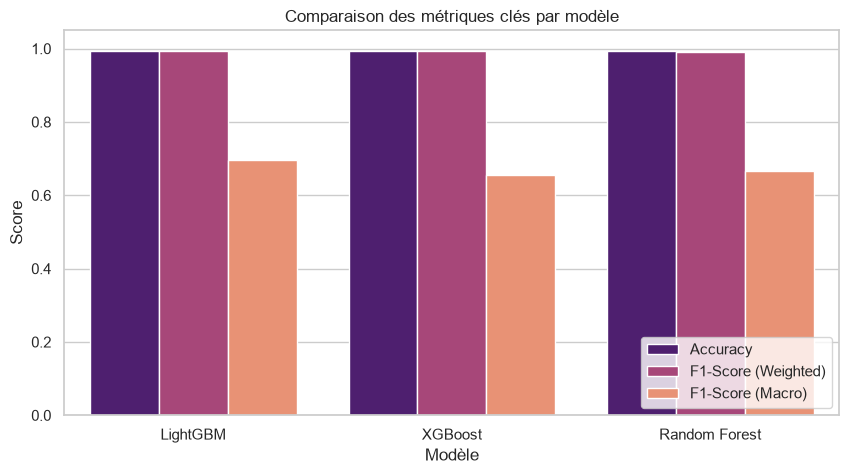

In [9]:
results = []

for name, y_pred in predictions.items():
    results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Weighted)": precision_score(y_test, y_pred, average='weighted'),
        "Recall (Weighted)": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score (Weighted)": f1_score(y_test, y_pred, average='weighted'),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average='macro')
    })

df_results = pd.DataFrame(results)
print("\n=== TABLEAU COMPARATIF DES PERFORMANCES ===")
display(df_results.sort_values(by="F1-Score (Macro)", ascending=False))

# Visualisation des métriques
plt.figure(figsize=(10, 5))
df_results_melted = df_results.melt(id_vars="Modèle", value_vars=["Accuracy", "F1-Score (Weighted)", "F1-Score (Macro)"])
sns.barplot(data=df_results_melted, x="Modèle", y="value", hue="variable", palette="magma")
plt.title("Comparaison des métriques clés par modèle")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.show()

## 6. Matrices de Confusion

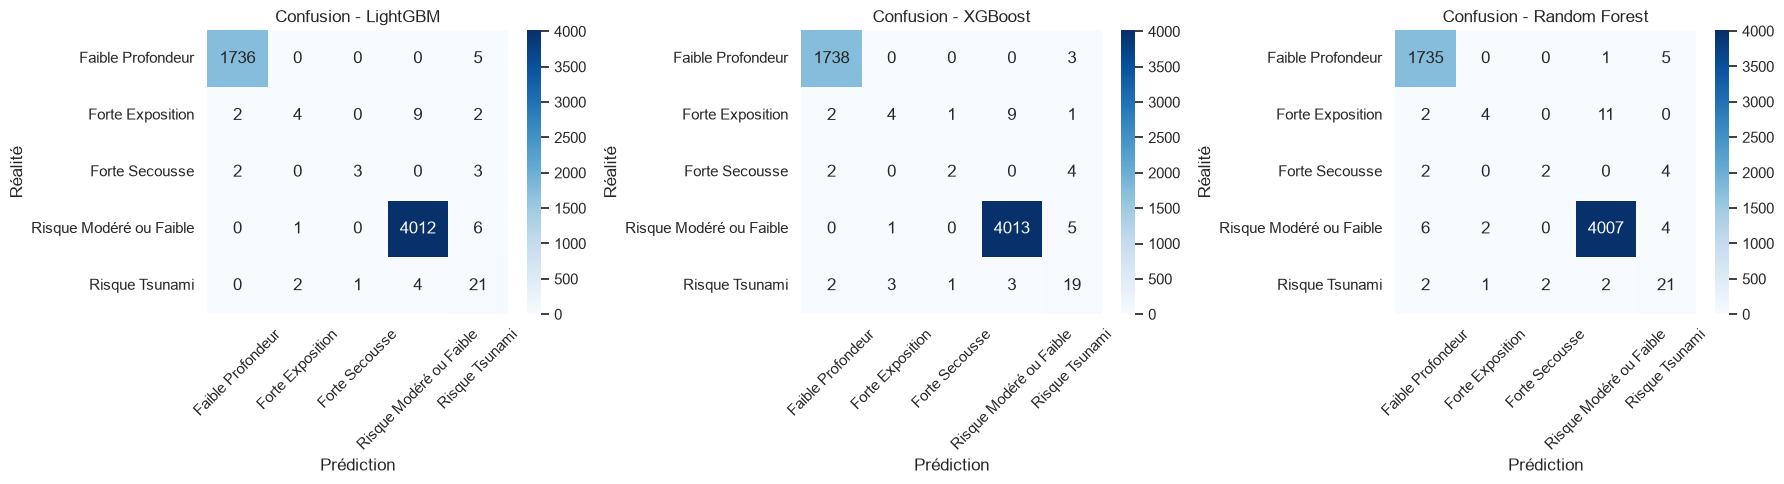

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  Récupérer les noms textuels pour l'affichage des axes
display_labels = label_encoder.classes_
labels_encoded = range(len(display_labels))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels_encoded)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=display_labels, yticklabels=display_labels)
    ax.set_title(f"Confusion - {name}")
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Réalité")
    #plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()